# E-Commerce Sales Analysis using Python

## 1. Business Objective

The goal of this project is to analyze e-commerce transaction data to identify:

- Overall revenue performance
- Sales trends over time
- Top-performing products
- Key revenue-generating countries
- High-value customers

This analysis aims to provide actionable insights to improve business decisions.

In [ ]:
# import python libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
import os
os.getcwd()

'C:\\Users\\HP\\Documents\\python-ecommerce-analysis\\notebooks'

In [21]:
os.listdir("../data")

['ecommerce.csv']

In [27]:
# import csv file
df = pd.read_csv('../data/ecommerce.csv', encoding= 'unicode_escape')

In [23]:
df.shape

(541909, 8)

## 2. Data Understanding

The dataset contains e-commerce transaction data including:

- Invoice details
- Product information
- Quantity and price
- Customer details
- Country of purchase

Initial exploration is performed to understand structure, data types, and missing values.

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [26]:
# describe() method returns description of the data in the DataFrame (i.e. count, mean, std, etc)
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [27]:
#check for null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [28]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [29]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 3. Data Cleaning

Data cleaning steps performed:

- Removed missing CustomerID values (cannot analyze customers without ID)
- Removed negative Quantity and UnitPrice (represent returns or invalid transactions)
- Ensured dataset contains only valid sales transactions

In [30]:
df = df.dropna(subset=['CustomerID'])

In [31]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [32]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [33]:
# checking the shape after dropping the null values
df.shape

(397884, 8)

In [35]:
# change data type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


## 4. Feature Engineering

New features created to support analysis:

- Revenue = Quantity × UnitPrice
- Month extracted from InvoiceDate for time-based analysis

In [38]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [44]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

## 5. Key Performance Indicators (KPIs)

Key metrics calculated:

- Total Revenue → overall business performance
- Total Orders → number of transactions
- Total Customers → unique customer count
- Average Order Value (AOV) → average revenue per order

In [56]:
# Total Revenue
df['Revenue'].sum()

np.float64(8911407.904)

In [57]:
# Total Orders
df['InvoiceNo'].nunique()

18532

In [58]:
# Total Customers
df['CustomerID'].nunique()

4338

In [62]:
#Average Order Value (AOV)
df['Revenue'].sum() / df['InvoiceNo'].nunique()

np.float64(480.8659563997409)

## 6. Exploratory Data Analysis

Analysis is performed to understand:

- Revenue trends over time
- Market performance by country
- Product performance
- Customer contribution to revenue

### 6.1 Monthly Revenue Trend

Purpose:
To analyze how revenue changes over time and identify growth patterns.


In [50]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

**Observation:**
Revenue peaks in November 2011, followed by a decline in December. Sales show fluctuations throughout the year.

**Insight:**
The business experiences strong seasonal demand toward the end of the year, likely due to holiday or festive season effects.

**Recommendation:**
Increase inventory and marketing efforts before peak months (Oct–Nov) and introduce promotions during low-performing months to stabilize revenue.

### 6.2 Sales by Country

Purpose:
To identify key markets contributing to revenue.

In [46]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

**Observation:**
The United Kingdom generates significantly higher revenue compared to all other countries.

**Insight:**
The business is highly dependent on the UK market, indicating strong customer concentration in a single region.

**Recommendation:**
Maintain strong customer engagement in the UK while expanding marketing efforts in other countries to reduce dependency risk.

### 6.3 Product Analysis

Purpose:
To identify top-selling and highest revenue-generating products.

In [60]:
top_selling = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_selling

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

**Observation:**
Products like PAPER CRAFT and LITTLE BIRDIE have the highest sales volume among all products.

**Insight:**
A small group of products contributes significantly to overall sales volume, indicating demand concentration.

**Recommendation:**
Ensure consistent availability of top-selling products and introduce similar products to capitalize on demand patterns.

In [61]:
top_revenue_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_revenue_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

**Observation:**
Products such as PAPER CRAFT and REGENCY CAKESTAND generate the highest revenue.

**Insight:**
High revenue is driven by a combination of product demand and pricing, not just quantity sold.

**Recommendation:**
Focus on promoting high-revenue products and optimize pricing strategies to maximize profitability.

### 6.4 Customer Analysis

Purpose:
To identify high-value customers contributing most to revenue.

In [59]:
most_valuable_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

most_valuable_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

**Observation:**
A small group of customers contributes a significant portion of total revenue.

**Insight:**
Revenue is concentrated among high-value customers, indicating the importance of customer retention.

**Recommendation:**
Implement loyalty programs and personalized offers for high-value customers while engaging low-value customers to increase their spending.

In [47]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
 9   Month        397884 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 33.4+ MB


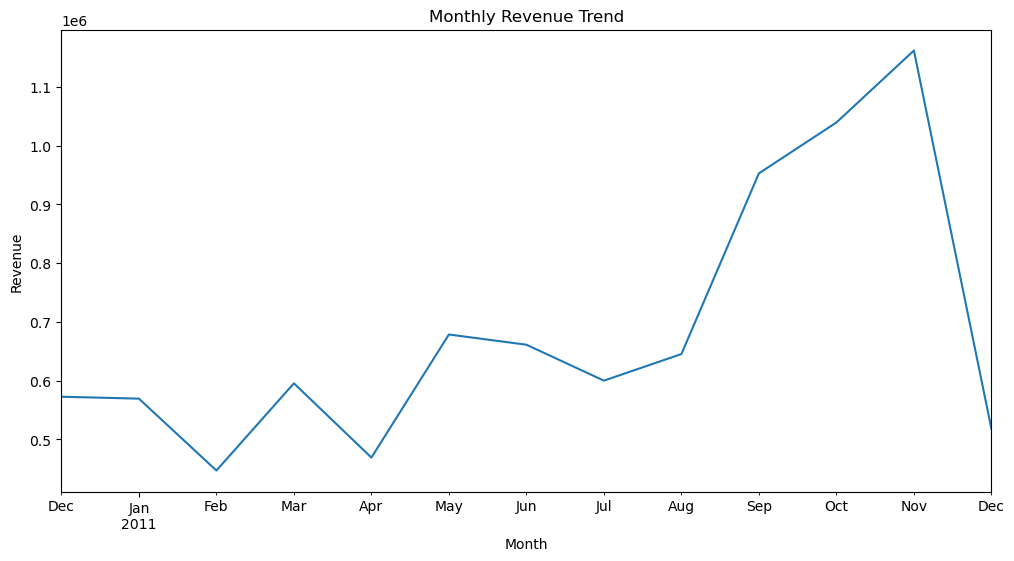

In [51]:
monthly_sales.plot(figsize=(12,6))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

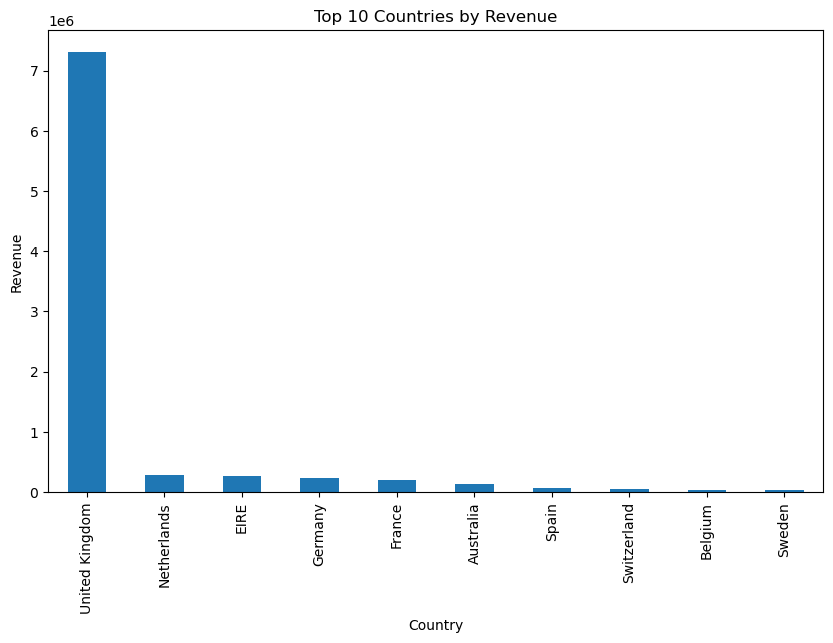

In [52]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

In [63]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [64]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [67]:
# Recency (reverse scoring)
r_bins = pd.qcut(rfm['Recency'], q=5, duplicates='drop')
rfm['R_Score'] = r_bins.cat.codes + 1
rfm['R_Score'] = 6 - rfm['R_Score']   # reverse

# Frequency
f_bins = pd.qcut(rfm['Frequency'], q=5, duplicates='drop')
rfm['F_Score'] = f_bins.cat.codes + 1

# Monetary
m_bins = pd.qcut(rfm['Monetary'], q=5, duplicates='drop')
rfm['M_Score'] = m_bins.cat.codes + 1

In [68]:
rfm[['R_Score','F_Score','M_Score']].head()

,R_Score,F_Score,M_Score
CustomerID,,,
12346.0,1,1,5
12347.0,5,4,5
12348.0,2,3,4
12349.0,4,1,4
12350.0,1,1,2


In [69]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [70]:
def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Best Customers'
    elif row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['R_Score'] <= 2:
        return 'At Risk Customers'
    else:
        return 'Average Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [71]:
rfm['Segment'].value_counts()

Segment
Average Customers    1965
At Risk Customers    1673
Best Customers        573
Loyal Customers       127
Name: count, dtype: int64

In [72]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,At Risk Customers
12347.0,2,7,4310.00,5,4,5,545,Best Customers
12348.0,75,4,1797.24,2,3,4,234,At Risk Customers
12349.0,19,1,1757.55,4,1,4,414,Average Customers
12350.0,310,1,334.40,1,1,2,112,At Risk Customers


## 7. Customer Segmentation (RFM Analysis)

Purpose:
To segment customers based on purchasing behavior (Recency, Frequency, Monetary) and identify high-value, loyal, and at-risk customers for targeted business strategies.

### Customer Distribution Analysis

**Observation:**
The majority of customers fall under the "Average Customers" and "At Risk Customers" segments, while a smaller proportion belongs to "Best Customers" and "Loyal Customers".

**Insight:**
Customer value is unevenly distributed. A large portion of customers are either inactive or contribute low value, while only a small group drives significant revenue.

**Business Meaning:**
The business relies heavily on a limited number of high-value customers, making customer retention a critical factor for sustained revenue.

### Best Customers

**Observation:**
A small group of customers falls into the "Best Customers" segment, characterized by recent purchases, high purchase frequency, and high spending.

**Insight:**
These customers are highly engaged and contribute a significant portion of total revenue.

**Business Action:**
- Offer loyalty rewards and exclusive deals
- Provide early access to new products
- Maintain strong engagement to retain them

**Why it matters:**
Losing these customers would have a direct and significant impact on revenue.

### Loyal Customers

**Observation:**
A smaller segment of customers shows high purchase frequency but may not have the highest monetary value.

**Insight:**
These customers are consistent buyers and have the potential to become high-value customers with proper engagement.

**Business Action:**
- Upsell premium products
- Offer bundle deals to increase average order value
- Encourage higher spending through targeted promotions

**Why it matters:**
This segment represents growth potential for increasing revenue.

### At Risk Customers

**Observation:**
A significant number of customers fall into the "At Risk Customers" segment, indicating they have not made recent purchases.

**Insight:**
These customers were previously active but are now disengaging, posing a risk of churn.

**Business Action:**
- Launch re-engagement campaigns (emails, discounts)
- Offer personalized promotions
- Identify reasons for inactivity

**Why it matters:**
Recovering these customers is often cheaper than acquiring new ones.

### Average Customers

**Observation:**
The largest group consists of "Average Customers" with moderate purchasing behavior.

**Insight:**
These customers contribute steadily but lack strong engagement or high spending.

**Business Action:**
- Improve engagement through targeted marketing
- Encourage repeat purchases
- Offer incentives to increase frequency and spending

**Why it matters:**
This segment has the potential to be converted into loyal or high-value customers.

### Overall Business Insights from RFM Analysis

- Revenue is concentrated among a small group of high-value customers.
- A large portion of customers are either average or at risk, indicating potential retention issues.
- There is a significant opportunity to improve customer engagement and increase customer lifetime value.

### Strategic Recommendations

- Focus on retaining best customers through loyalty programs.
- Convert loyal customers into high-value customers via upselling.
- Re-engage at-risk customers with targeted campaigns.
- Improve engagement strategies for average customers to increase their value.

## 8. Final Business Insights & Recommendations

### Overall Business Performance

The business generated strong revenue across the observed period, with noticeable growth trends and seasonal fluctuations.

Sales peaked during the end of the year, indicating the presence of seasonal demand, likely driven by holidays or festive periods.

### Market Insights

The United Kingdom is the dominant market, contributing the majority of total revenue.

This indicates a strong customer base in the UK but also highlights a potential dependency risk on a single region.

Other countries contribute significantly less, suggesting opportunities for market expansion.

### Product Performance Insights

A small group of products drives a large portion of total sales and revenue.

This indicates that demand is concentrated among specific products, making inventory management and product availability critical.

At the same time, many products contribute less, indicating opportunities for optimization or promotion.

### Customer Behavior Insights

Customer segmentation reveals that:

- A small percentage of customers contribute a significant portion of revenue (Best Customers)
- A large number of customers fall into average and at-risk categories
- Customer engagement is uneven, with many customers not actively purchasing

This highlights the importance of customer retention and engagement strategies.

### Key Business Challenges Identified

- Heavy reliance on a single market (UK)
- Revenue concentration among a small group of customers
- High number of at-risk customers indicating potential churn
- Uneven product performance across inventory

### Strategic Recommendations

1. Customer Retention:
   Focus on retaining high-value customers through loyalty programs and personalized offers.

2. Re-engagement Strategy:
   Target at-risk customers with discounts and marketing campaigns to bring them back.

3. Market Expansion:
   Invest in expanding presence in other countries to reduce dependency on the UK.

4. Product Strategy:
   Ensure availability of top-performing products while promoting underperforming ones.

5. Seasonal Planning:
   Prepare inventory and marketing campaigns ahead of peak sales periods to maximize revenue.

## 9. Conclusion & Business Summary

### Executive Summary

This analysis explored e-commerce transaction data to evaluate business performance, customer behavior, and revenue drivers.

Key findings indicate that the business is performing well overall, with strong revenue generation and clear seasonal trends. However, revenue and customer value are highly concentrated in specific segments, highlighting both strengths and potential risks.

The insights derived from this analysis can support strategic decision-making to improve customer retention, expand market reach, and optimize product performance.

### Key Findings

- Revenue shows seasonal growth, with peak performance in the final months of the year.
- The United Kingdom is the primary revenue-generating market.
- A small group of products contributes significantly to overall sales.
- Customer value is unevenly distributed, with a small percentage of high-value customers driving most revenue.
- A large number of customers fall into the "at-risk" category, indicating potential churn.

### Business Implications

- The business is highly dependent on a single market (UK), which may pose a risk if demand declines.
- Revenue concentration among a few customers makes retention strategies critical.
- High number of at-risk customers suggests a need for improved engagement.
- Product demand concentration requires careful inventory and marketing planning.

### Final Recommendations

1. Strengthen Customer Retention:
   Focus on retaining high-value customers through loyalty programs and personalized engagement.

2. Re-engage At-Risk Customers:
   Implement targeted campaigns and incentives to bring inactive customers back.

3. Expand Market Presence:
   Explore growth opportunities in other countries to reduce dependency on the UK market.

4. Optimize Product Strategy:
   Ensure availability of top-performing products while promoting underperforming items.

5. Leverage Seasonal Trends:
   Align marketing and inventory strategies with peak sales periods to maximize revenue.

### Final Statement

This analysis demonstrates how data-driven insights can be used to understand customer behavior, identify business risks, and uncover growth opportunities.

By implementing the recommended strategies, the business can improve customer retention, increase revenue, and achieve more sustainable growth.